# 🌋 Geyser Eruption Prediction: ML for Natural Hazard Monitoring

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **Geoscience Australia** — Geothermal monitoring, natural hazard assessment
- **BOM** — Environmental monitoring networks
- **CSIRO** — Geothermal energy research
- **Emergency Management Australia** — Natural hazard early warning

Dataset: seaborn built-in geyser — NO dataset needed. 272 samples.

---

## 1. Data Loading

In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
df=sns.load_dataset('geyser')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i}. {col:15s} | {str(df[col].dtype):10s} | uniq={df[col].nunique()}")
df.head()

Loaded: 272 x 3
  0. duration        | float64    | uniq=126
  1. waiting         | int64      | uniq=51
  2. kind            | object     | uniq=2


,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


## 2. Target & EDA

Target: 'duration' (eruption duration in minutes)
count    272.000000
mean       3.487783
std        1.141371
min        1.600000
25%        2.162750
50%        4.000000
75%        4.454250
max        5.100000
Name: duration, dtype: float64


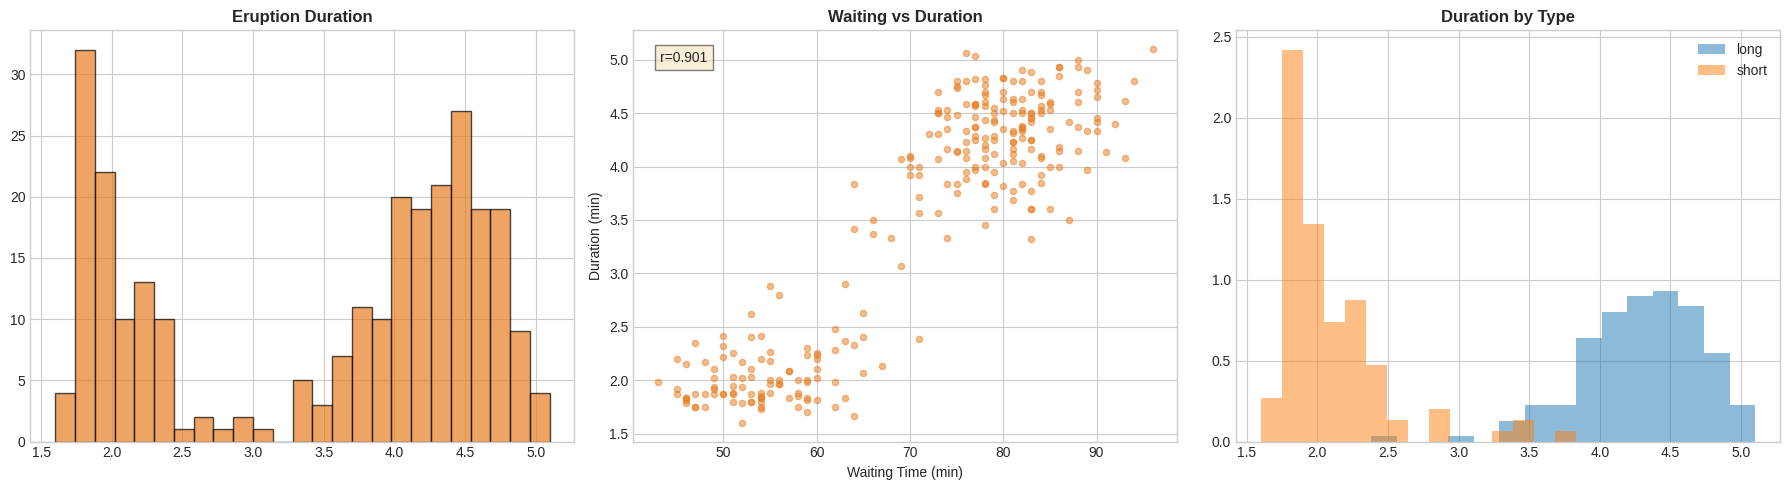

AU: Geoscience Australia monitors geothermal activity across the continent.


In [2]:
tc='duration'
print(f"Target: '{tc}' (eruption duration in minutes)");print(df[tc].describe())
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].hist(df[tc],bins=25,color='#e67e22',edgecolor='black',alpha=0.7)
axes[0].set_title('Eruption Duration',fontweight='bold')
axes[1].scatter(df['waiting'],df[tc],alpha=0.5,s=20,color='#e67e22')
axes[1].set_xlabel('Waiting Time (min)');axes[1].set_ylabel('Duration (min)')
axes[1].set_title('Waiting vs Duration',fontweight='bold')
r=df[['waiting',tc]].corr().iloc[0,1]
axes[1].text(0.05,0.95,f'r={r:.3f}',transform=axes[1].transAxes,va='top',bbox=dict(facecolor='wheat',alpha=0.5))
for kind in df['kind'].unique():
    s=df[df['kind']==kind][tc]
    axes[2].hist(s,bins=15,alpha=0.5,label=kind,density=True)
axes[2].set_title('Duration by Type',fontweight='bold');axes[2].legend()
plt.tight_layout();plt.savefig('eda.png',dpi=150);plt.show()
print("AU: Geoscience Australia monitors geothermal activity across the continent.")

## 3-4. Preprocessing & Training

In [3]:
le=LabelEncoder();df['kind_enc']=le.fit_transform(df['kind'])
X=df[['waiting','kind_enc']];y=df[tc].values
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        r2=np.sqrt(mean_squared_error(y[vi],yp));m3=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r2);fm.append(m3);f2.append(s);print(f"  Fold{fi+1}: RMSE={r2:.3f} MAE={m3:.3f} R2={s:.4f}")
    el=time.time()-t0;results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.3f} R2={np.mean(f2):.4f}")


Ridge
  Fold1: RMSE=0.397 MAE=0.299 R2=0.8561
  Fold2: RMSE=0.428 MAE=0.321 R2=0.8507
  Fold3: RMSE=0.342 MAE=0.274 R2=0.9224
  AVG: RMSE=0.389 R2=0.8764

RF
  Fold1: RMSE=0.432 MAE=0.332 R2=0.8294
  Fold2: RMSE=0.431 MAE=0.323 R2=0.8490
  Fold3: RMSE=0.462 MAE=0.361 R2=0.8579
  AVG: RMSE=0.442 R2=0.8454

XGB
  Fold1: RMSE=0.431 MAE=0.332 R2=0.8301
  Fold2: RMSE=0.454 MAE=0.341 R2=0.8324
  Fold3: RMSE=0.526 MAE=0.398 R2=0.8161
  AVG: RMSE=0.470 R2=0.8262

LGBM
  Fold1: RMSE=0.417 MAE=0.319 R2=0.8409
  Fold2: RMSE=0.425 MAE=0.312 R2=0.8532
  Fold3: RMSE=0.381 MAE=0.308 R2=0.9037
  AVG: RMSE=0.407 R2=0.8659


## 5. Comparison & Residuals

COMPARISON
Model  RMSE   MAE     R2
Ridge 0.389 0.298 0.8764
 LGBM 0.407 0.313 0.8659
   RF 0.442 0.339 0.8454
  XGB 0.470 0.357 0.8262

Best: Ridge


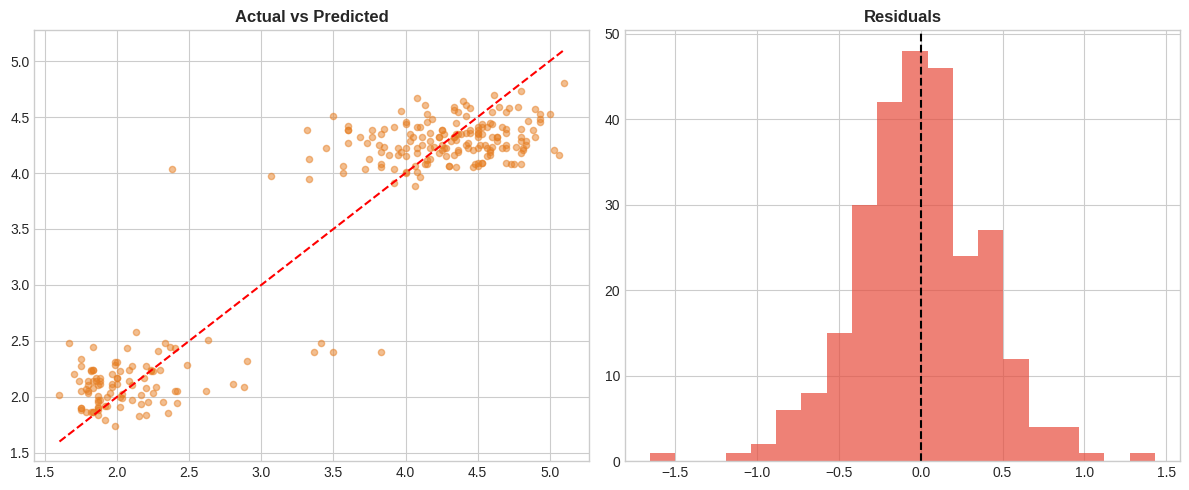

In [4]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.3f}",'MAE':f"{v['mae']:.3f}",'R2':f"{v['r2']:.4f}",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*60);print(sdf[['Model','RMSE','MAE','R2']].to_string(index=False));print(f"\nBest: {best}")
bp=results[best]['preds'];res=y-bp
fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].scatter(y,bp,alpha=0.5,s=20,color='#e67e22');lm=[min(y.min(),bp.min()),max(y.max(),bp.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(res,bins=20,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
plt.tight_layout();plt.savefig('resid.png',dpi=150);plt.show()

## 6. Deployment

In [5]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}  R2: {br['r2']:.4f}  MAE: {br['mae']:.3f} min")
print(f"  Feats: {X.shape[1]}  Rows: {len(y)}")
print("  Architecture: Seismic sensors -> Geoscience Australia -> eruption timing prediction")

DEPLOYMENT READINESS
  Model: Ridge  R2: 0.8764  MAE: 0.298 min
  Feats: 2  Rows: 272
  Architecture: Seismic sensors -> Geoscience Australia -> eruption timing prediction
